<a href="https://colab.research.google.com/github/BigamPachhai/ML-Projects/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [5]:
X,y_true = make_blobs(n_samples=600, centers=4, cluster_std=0.6, random_state=0)

In [6]:
X

array([[ 1.72268175,  0.61528107],
       [-1.08684133,  8.15041073],
       [ 1.07568681, -0.04299697],
       ...,
       [ 0.45976418,  1.26145537],
       [ 0.76752279,  4.39759671],
       [ 0.79850568,  0.97189681]])

In [8]:
df=pd.DataFrame(X,columns=['feature 1','feature 2'])

In [9]:
df

,feature 1,feature 2
0,1.722682,0.615281
1,-1.086841,8.150411
2,1.075687,-0.042997
3,2.764095,0.518521
4,-1.350111,7.754980
...,...,...
595,-1.781702,2.419904
596,-1.032553,7.748720
597,0.459764,1.261455
598,0.767523,4.397597


In [11]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df)

In [13]:
inertia=[]
K_range=range(1,11)

In [14]:
for k in K_range:
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [15]:
inertia

[1200.000000000001,
 536.2905498946178,
 274.92267621865284,
 111.76416922506088,
 99.65511826670586,
 85.06829245372415,
 73.22781860144737,
 69.9367659951413,
 55.27151594280114,
 52.171469591210425]

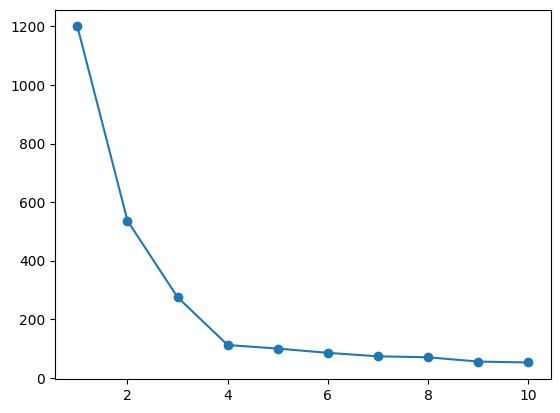

In [19]:
plt.plot(K_range,inertia,marker='o')

In [31]:
kmeans_final=KMeans(n_clusters=6,random_state=42)

In [32]:
from sklearn import cluster
cluster_labels=kmeans_final.fit_predict(X_scaled)

In [33]:
df['clusters']=cluster_labels

<Axes: xlabel='feature 1', ylabel='feature 2'>

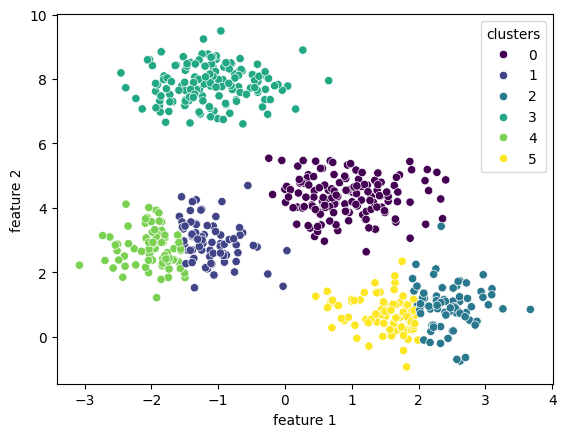

In [34]:
sns.scatterplot(x=df['feature 1'],
                y=df['feature 2'],
                hue='clusters',
                palette='viridis',
                data=df)